# 01 · EDA del dataset de churn

Dataset de `00_datos/build_dataset.py`: una fila por (vendedora, mes observado), 42 variables transaccionales
(36 del SQL + 6 derivadas), etiqueta `churn` = sin compras en los 6 meses siguientes.

Objetivo: confirmar balance de clases, estabilidad temporal, estructura del panel, completitud, forma de las
distribuciones, señal univariada y redundancia. La última celda escribe `reports/eda.md` con los números reales.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import datos, particion
pd.set_option("display.width", 160)
df = datos.load()
FEATS = datos.features(df)
print(df.shape, "| variables:", len(FEATS))

(31235, 46) | variables: 42


## 1 · Target: balance de clases

In [2]:
bal = df.churn.value_counts().rename({0: "activa", 1: "churn"}).to_frame("n")
bal["pct"] = (bal.n / bal.n.sum()).round(4)
bal

,n,pct
churn,,
activa,21602,0.6916
churn,9633,0.3084


## 2 · Estabilidad temporal del target

Prevalencia y volumen por mes observado. Importa porque la validación es temporal: un cambio de régimen en los
últimos meses afecta directamente al test OOT.

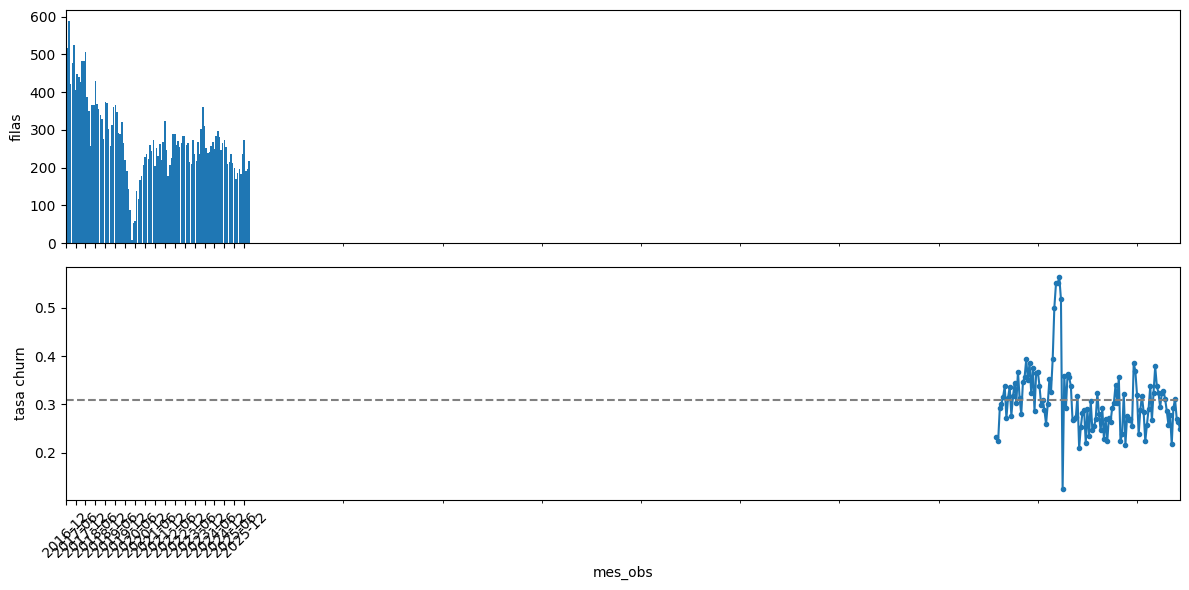

,n,churn
mes_obs,,
2016,514,0.2335
2017,5719,0.3029
2018,4195,0.3490
2019,3700,0.3489
2020,1576,0.3693
2021,2997,0.2663
2022,3053,0.2784
2023,3149,0.2972
2024,3153,0.2953


In [3]:
mes = df.groupby(df.mes_obs.dt.to_period("M")).agg(n=("churn", "size"), churn=("churn", "mean"))
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
mes.n.plot.bar(ax=ax[0], width=0.9); ax[0].set_ylabel("filas")
mes.churn.plot(ax=ax[1], marker="."); ax[1].axhline(df.churn.mean(), ls="--", c="gray"); ax[1].set_ylabel("tasa churn")
ax[1].set_xticks(range(0, len(mes), 6)); ax[1].set_xticklabels(mes.index.astype(str)[::6], rotation=45)
plt.tight_layout(); plt.show()
anual = df.groupby(df.mes_obs.dt.year).agg(n=("churn", "size"), churn=("churn", "mean")).round(4)
anual

## 3 · Estructura del panel (multi-slicing)

Cada vendedora aparece en varios meses. Esto es lo que justifica GroupKFold como verificación complementaria.

In [4]:
por_vend = df.groupby("id_vendedor").size()
print(f"vendedoras: {len(por_vend):,} | filas/vendedora: mediana {por_vend.median():.0f}, "
      f"media {por_vend.mean():.1f}, max {por_vend.max()}")
por_vend.describe().round(1).to_frame("filas_por_vendedora").T

vendedoras: 6,386 | filas/vendedora: mediana 2, media 4.9, max 88


,count,mean,std,min,25%,50%,75%,max
filas_por_vendedora,6386.0,4.9,7.2,1.0,1.0,2.0,5.0,88.0


## 4 · Completitud

Los nulos del SQL son estructurales (sin historia suficiente para un ratio o un LAG) y se imputan a cero en
`datos.preprocess`. Se comprueba el antes y el después.

In [5]:
raw = pd.read_csv(datos.RAW)
nulos = raw.isna().mean().loc[lambda s: s > 0].sort_values(ascending=False).round(4).to_frame("pct_nulos_raw")
nulos["pct_nulos_processed"] = df[nulos.index].isna().mean().round(4)
nulos

,pct_nulos_raw,pct_nulos_processed
d_monto_m12,0.4824,0.0
d_nped_m12,0.4824,0.0
d_monto_m9,0.4116,0.0
d_nped_m9,0.4116,0.0
d_monto_m6,0.3195,0.0
d_nped_m6,0.3195,0.0
tend_monto_u3_vs_prev3,0.1776,0.0
tend_nped_u3_vs_prev3,0.1769,0.0
d_monto_m3,0.1769,0.0
d_nped_m3,0.1769,0.0


## 5 · Distribuciones de las variables

In [6]:
desc = df[FEATS].describe().T
desc["skew"] = df[FEATS].skew().round(2)
desc["pct_ceros"] = (df[FEATS] == 0).mean().round(3)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,pct_ceros
meses_activos_u3,31235.0,1.91,0.76,1.00,1.00,2.00,2.00,3.00,0.15,0.00
meses_activos_u6,31235.0,2.89,1.46,1.00,2.00,3.00,4.00,6.00,0.57,0.00
meses_activos_u12,31235.0,4.28,2.72,1.00,2.00,3.00,6.00,12.00,1.01,0.00
n_ped_u3,31235.0,2.75,2.32,1.00,1.00,2.00,3.00,46.00,4.37,0.00
n_ped_u6,31235.0,4.27,3.97,1.00,2.00,3.00,5.00,82.00,4.47,0.00
n_ped_u12,31235.0,6.43,6.55,1.00,3.00,4.00,8.00,112.00,4.07,0.00
monto_u3,31235.0,1076.35,1387.84,0.00,392.30,728.89,1258.74,34534.09,6.65,0.00
monto_u6,31235.0,1716.07,2379.83,0.00,582.90,1078.87,1990.71,53527.24,6.45,0.00
monto_u12,31235.0,2656.64,4011.03,0.00,761.90,1484.76,3005.98,90545.57,6.35,0.00
monto_mean_u12,31235.0,337.40,442.16,0.00,106.79,229.19,409.62,8553.15,6.01,0.00


## 6 · Señal univariada

AUC de cada variable tomada sola como score (orientada: `max(auc, 1-auc)`). Es un diagnóstico, no una
selección: la selección se hace dentro de cada fold en `02_variables`.

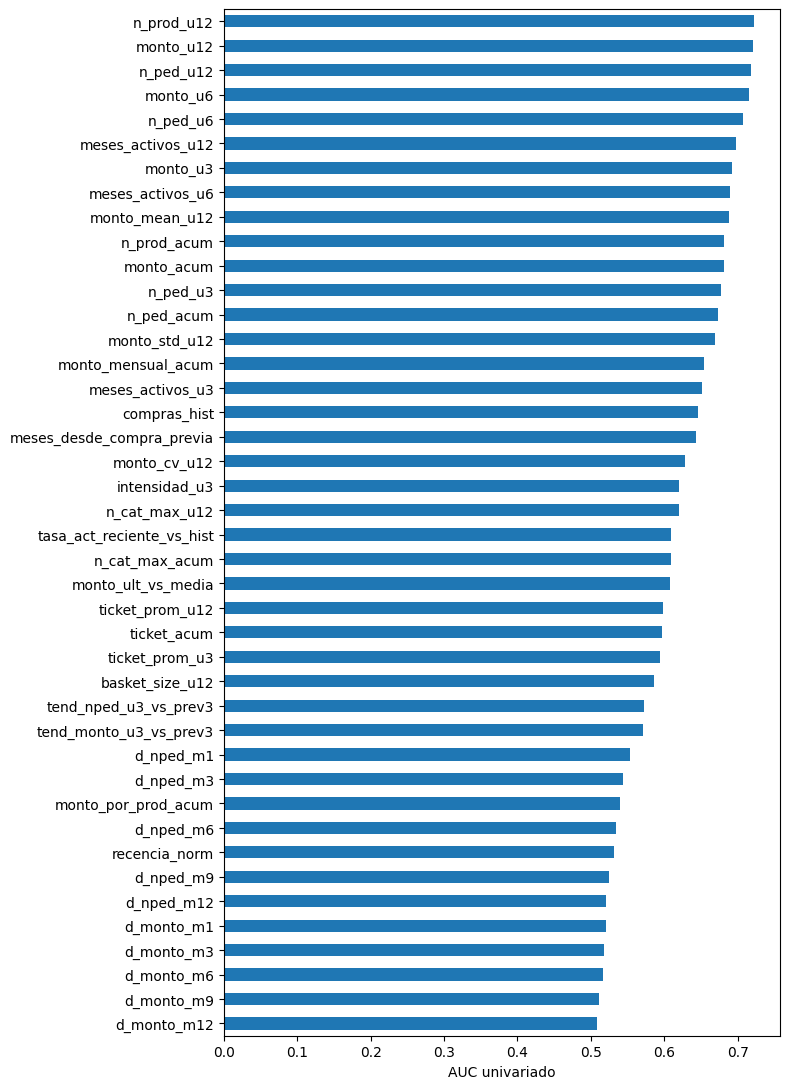

,auc,direccion
n_prod_u12,0.7216,- churn
monto_u12,0.7215,- churn
n_ped_u12,0.7178,- churn
monto_u6,0.7149,- churn
n_ped_u6,0.7077,- churn
meses_activos_u12,0.6977,- churn
monto_u3,0.6926,- churn
meses_activos_u6,0.6900,- churn
monto_mean_u12,0.6878,- churn
n_prod_acum,0.6812,- churn


In [7]:
from sklearn.metrics import roc_auc_score
uni = pd.Series({f: roc_auc_score(df.churn, df[f]) for f in FEATS})
uni = pd.DataFrame({"auc": uni, "direccion": np.where(uni >= 0.5, "+ churn", "- churn")})
uni["auc"] = np.maximum(uni.auc, 1 - uni.auc)
uni = uni.sort_values("auc", ascending=False).round(4)
uni.auc.plot.barh(figsize=(8, 11)).invert_yaxis(); plt.xlabel("AUC univariado"); plt.tight_layout(); plt.show()
uni.head(15)

## 7 · Redundancia

Pares de variables con |r de Spearman| ≥ 0.9. Las ventanas u3/u6/u12 de una misma métrica son correlacionadas por
construcción; la reducción de variables se decide en `02_variables`, no aquí.

In [8]:
corr = df[FEATS].corr("spearman")
pares = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
         .loc[lambda s: s.abs() >= 0.9].sort_values(ascending=False).round(3).rename("rho").reset_index())
print(f"{len(pares)} pares con |rho| >= 0.9")
pares

11 pares con |rho| >= 0.9


,level_0,level_1,rho
0,monto_acum,n_prod_acum,0.986
1,monto_u12,n_prod_u12,0.977
2,compras_hist,n_ped_acum,0.944
3,n_ped_acum,n_prod_acum,0.940
4,monto_acum,n_ped_acum,0.930
5,meses_activos_u12,n_ped_u12,0.922
6,tend_monto_u3_vs_prev3,tend_nped_u3_vs_prev3,0.912
7,ticket_acum,ticket_prom_u12,0.906
8,compras_hist,n_prod_acum,0.905
9,n_ped_u12,n_prod_u12,0.904


## 8 · Reporte

In [9]:
out = datos.ROOT / "reports" / "eda.md"
dev, oot = particion.oot_split(df.mes_rank)
texto = f"""# EDA — dataset de churn (sem2)

Generado por `01_eda/eda.ipynb`. Fuente: `data/churn_dataset_processed.csv`.

## Dataset
- {len(df):,} filas (vendedora-mes), {df.id_vendedor.nunique():,} vendedoras, {len(FEATS)} variables.
- Meses observados: {df.mes_obs.min():%Y-%m} → {df.mes_obs.max():%Y-%m}.
- Prevalencia de churn: **{df.churn.mean():.2%}** ({int(df.churn.sum()):,} positivos).
- Filas por vendedora: mediana {por_vend.median():.0f}, máximo {por_vend.max()}.

## Estabilidad temporal (prevalencia por año)
{anual.to_markdown()}

Últimos 4 meses (OOT): prevalencia {df[oot].churn.mean():.2%} con {oot.sum():,} filas.

## Completitud
{len(nulos)} columnas con nulos en el SQL (máximo {nulos.pct_nulos_raw.max():.1%}); 0 nulos tras `preprocess`.

## Señal univariada (top 10 por AUC)
{uni.head(10).to_markdown()}

## Redundancia
{len(pares)} pares con |rho de Spearman| >= 0.9.
"""
out.write_text(texto)
print(f"-> {out}")

-> /Users/carlosescobar/Projects/Glamour/customer-churn-prediction/sem2_draft/reports/eda.md
